In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from plot_utils import plot_results


In [40]:
action_spaces = [
    "joint-velocity",
    "joint-torque",
    "cartesian_increment-position",
    "joint_increment-position",
]

In [41]:
prefix = "PandaPickCubeCartesianModified"
postfix="_prop-seed"

In [42]:
logs_dir = "../logs"
# resolve logsdir

logs_dir = os.path.abspath(logs_dir)
logs_dir


'/home/sazimi/Desktop/ICRA2026/training/logs'

In [43]:
## List path of all event files in directory

# recursively list all event files under logs_dir
event_files = []
for root, _, files in os.walk(logs_dir):
    for f in files:
        if f.startswith("events.out.tfevents"):
            event_files.append(os.path.join(root, f))
event_files, len(event_files);

In [44]:
# group the runs
run_groups = {}

for action_space in action_spaces:
    run_groups[action_space] = []
    for ef in event_files:
        parent = os.path.basename(os.path.dirname(ef))
        if action_space in ef:
            run_groups[action_space].append(ef)

# deduplicate and sort each group
for k in run_groups:
    run_groups[k] = sorted(set(run_groups[k]))

# show counts per group
{k: len(v) for k, v in run_groups.items()}

{'joint-velocity': 10,
 'joint-torque': 10,
 'cartesian_increment-position': 10,
 'joint_increment-position': 10}

In [45]:
## Let's first plot results for one action space

tb_tags_list = [
    "episode/success",
    "episode/sum_reward",
    "episode/floor_collision",
    "episode/jerk"
]

In [46]:
axis_tag_names = {
    "episode/success": "Success Rate",
    "episode/sum_reward": "Episodic Return",
    "episode/floor_collision": "Floor Collisions",
    "episode/jerk": "Jerk",
}

generating plot
Processing tag 'episode/success' with 977 rows
Processing tag 'episode/sum_reward' with 977 rows
Processing tag 'episode/floor_collision' with 977 rows
Processing tag 'episode/jerk' with 977 rows
Processing tag 'episode/success' with 2444 rows
Processing tag 'episode/sum_reward' with 2444 rows
Processing tag 'episode/floor_collision' with 2444 rows
Processing tag 'episode/jerk' with 2444 rows
Processing tag 'episode/success' with 980 rows
Processing tag 'episode/sum_reward' with 980 rows
Processing tag 'episode/floor_collision' with 980 rows
Processing tag 'episode/jerk' with 980 rows
Processing tag 'episode/success' with 980 rows
Processing tag 'episode/sum_reward' with 980 rows
Processing tag 'episode/floor_collision' with 980 rows
Processing tag 'episode/jerk' with 980 rows


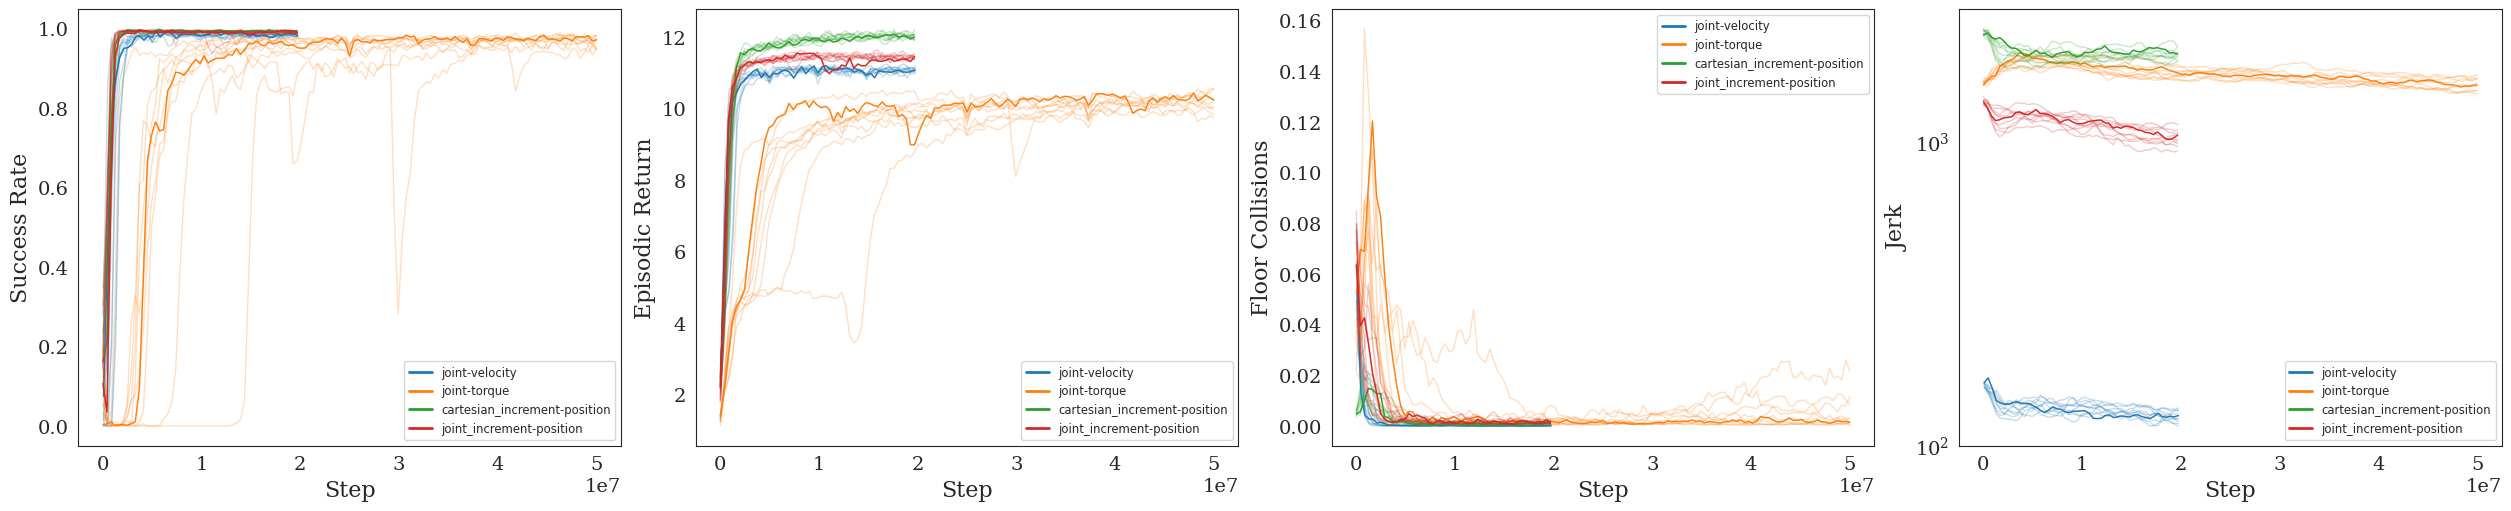

In [47]:

plot_results(run_groups)